In [38]:
#!pip install numpy scikit-learn matplotlib

In [39]:
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt

from sklearn import model_selection
from sklearn.datasets import load_digits

In [40]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [41]:
data = digits["data"]
images = digits["images"]
target = digits["target"]
target_names = digits["target_names"]

data[0].shape, images[0].shape, target[0], target_names[0]

((64,), (8, 8), np.int64(0), np.int64(0))

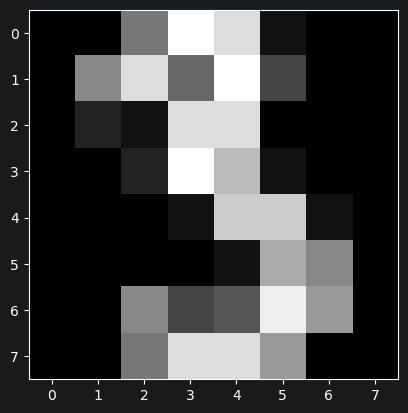

In [42]:
img = images[target == 3][0]
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

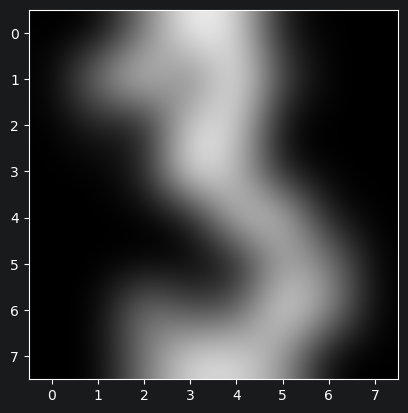

In [43]:
plt.imshow(img, interpolation = "bicubic") # also try interpolation = "bicubic"

In [44]:
filter = (target % 3 == 0) * (target % 2 != 0)

filtered_data = data[filter]
filtered_target = target[filter]

filtered_target[filtered_target==3] = -1
filtered_target[filtered_target==9] = 1

filtered_target

array([-1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
        1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,
        1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,
        1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,
        1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,
        1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,
        1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,
        1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,
        1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
       -1,  1,  1, -1, -1

In [45]:
X_all = filtered_data #/ 255
y_all = filtered_target

X_train, X_test, y_train, y_test =\
    model_selection.train_test_split(X_all, y_all,
        test_size = 0.4 , random_state = 0)

(8, 8)


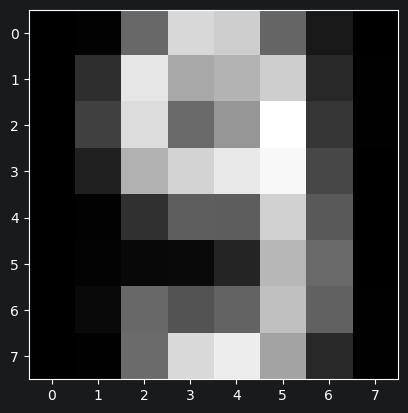

In [46]:
img = X_train[y_train == 1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


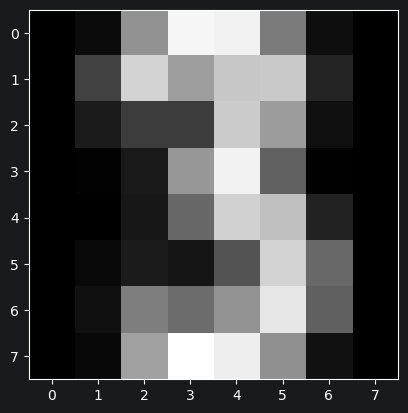

In [47]:
img = X_train[y_train == -1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


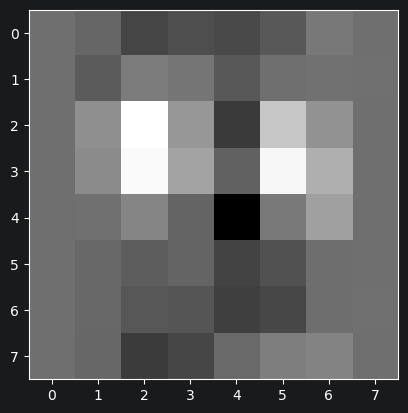

In [48]:
img = (X_train[y_train == 1].mean(axis=0) - X_train[y_train == -1].mean(axis=0)).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [49]:
def handcrafted_conv(x):
    conv_matrix = np.array([[0,0,0,0], [0,0,0,0], [0.5, -1, 1, -0.5], [0.5, -1, 1, -0.5]])

    print((x * conv_matrix).shape)
    
    val = (x[:] * conv_matrix).sum(axis=2).sum(axis=1)

    return val




In [50]:
# def features2d(x: np.array):
#     f_1 = x[:, 2*8+2] + x[:, 3*8+2] - 15# * 2 #- x[:, 2*8+1] * 2
#     f_2 = x[:, 2*8+5] *0.5 + x[:, 3*8+5] - 15
#
#     return f_1, f_2

# def features2d(x: np.array):
#     f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2
#     f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5
#
#     return f_1, f_2

# Flatten features to 2d hand-crafted feature space
def features2d(x: np.array):
    f_1 = x[:, 2*8+2] * 4 + x[:, 3*8+2] * 8#- 15# * 2 #- x[:, 2*8+1] * 2
    f_2 = x[:, 2*8+5] * 5 + x[:, 3*8+5] * 9#- 15

    return f_1, f_2

In [51]:
X_train[:4]

array([[ 0.,  0.,  0.,  1., 12., 16., 14.,  0.,  0.,  0.,  3., 14., 13.,
        15., 13.,  0.,  0.,  4., 16., 15., 13., 16.,  4.,  0.,  0.,  3.,
        16., 16., 16., 16.,  3.,  0.,  0.,  0.,  7.,  7., 14., 14.,  0.,
         0.,  0.,  0.,  0.,  0., 12., 11.,  0.,  0.,  0.,  0.,  0.,  0.,
        13., 10.,  0.,  0.,  0.,  0.,  0.,  0., 13., 12.,  0.,  0.],
       [ 0.,  0.,  9., 16., 14.,  6.,  0.,  0.,  0.,  6., 16.,  5., 10.,
        16.,  0.,  0.,  0.,  2., 15.,  7., 10., 16.,  3.,  0.,  0.,  0.,
         4.,  8., 12., 16.,  4.,  0.,  0.,  0.,  0.,  0.,  0., 16.,  7.,
         0.,  0.,  0.,  0.,  0.,  1., 16.,  8.,  0.,  0.,  0.,  3.,  0.,
         8., 16.,  1.,  0.,  0.,  0., 10., 16., 13.,  4.,  0.,  0.],
       [ 0.,  0.,  8., 14., 12.,  3.,  0.,  0.,  0.,  6., 16.,  6., 14.,
        14.,  0.,  0.,  0.,  6., 13.,  0.,  8., 14.,  0.,  0.,  0.,  2.,
        14., 14., 14., 16.,  3.,  0.,  0.,  0.,  2.,  4.,  6., 16.,  5.,
         0.,  0.,  0.,  0.,  0.,  0., 16.,  5.,  0.,  0.,  

In [52]:
x = X_train

print(x.shape)

features = features2d(x)

(217, 64)


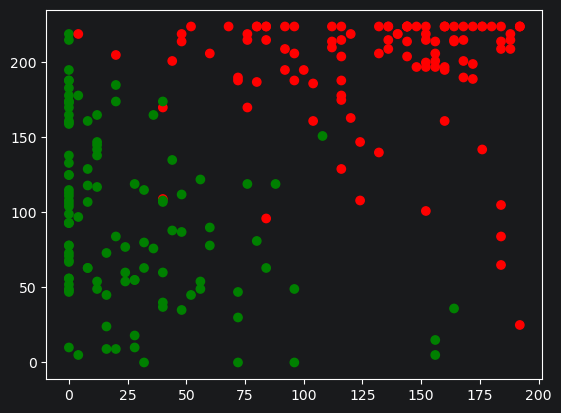

In [53]:
# Visually Inspect the distribution of the instances of the new feature
features = features2d(x)

color_dict = {-1: "green", 1: "red"} # Where green is 3s and red is 9s
colors = [color_dict[y] for y in y_train]

matplotlib.pyplot.scatter(features[0], features[1], c=colors)

In [54]:
# Find the mean of the 2D feature vectors of each class in the training set and assign each test instance to the label of the nearest mean
def nearest_mean(training_features, training_labels, test_features):
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()

    predicted_labels = np.array([1 if abs((x_9_mean - test_features[0][i])**2 + (y_9_mean - test_features[1][i])**2) < (x_3_mean - test_features[0][i])**2 + (y_3_mean - test_features[1][i])**2 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

# Decision rule function
def descision_function(training_features, training_labels, test_features):
    beta1 = 1/210
    beta2 = 1/220
    b1 = -0.5
    b2 = -0.5
            
    predicted_labels = np.array([1 if (test_features[0][i]*beta1 + b1) + (test_features[1][i]*beta2 + b2) > 0 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

In [55]:
training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1

predicted_labels = nearest_mean(training_features, training_labels, test_features)

In [56]:
predicted_labels

array([ 1,  1,  1, -1, -1,  1, -1,  1, -1, -1, -1, -1,  1, -1,  1, -1, -1,
        1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,
       -1,  1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1,
       -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1, -1,
       -1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,
        1,  1,  1, -1, -1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1, -1,  1, -1, -1, -1,  1,  1])

In [57]:
#F P +#F N
#    N
def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])

    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N

In [58]:
true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)
errors

(np.int64(72),
 np.int64(71),
 np.int64(1),
 np.int64(2),
 146,
 np.float64(0.02054794520547945),
 np.float64(0.9794520547945206))

In [59]:
# Prepare 2d features and labels
training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1

# Run nearest mean and decision function to compare against each other
predicted_labels = nearest_mean(training_features, training_labels, test_features)
predicted_labels2 = descision_function(training_features, training_labels, test_features)

true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)
errors2 = calculate_errors(predicted_labels2, true_labels)

errors[-1], errors[-2], errors2[-1], errors2[-2]

(np.float64(0.9794520547945206),
 np.float64(0.02054794520547945),
 np.float64(0.9794520547945206),
 np.float64(0.02054794520547945))

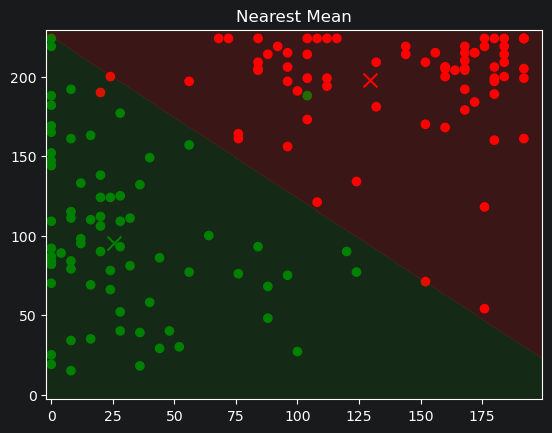

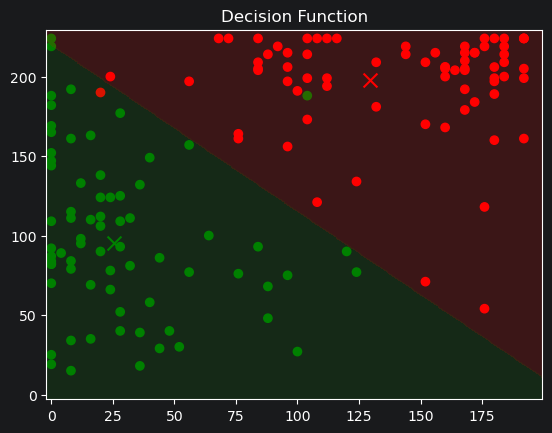

In [60]:
color_dict = {-1: "green", 1: "red"}
colors = [color_dict[y] for y in true_labels]

x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()

# Create a grid for plotting decision regions
xx, yy = np.meshgrid(np.arange(-2, 200, 0.5), np.arange(-3, 230, 0.5))
grid = (xx.ravel(), yy.ravel())

# Create plots
for func, name in [(nearest_mean, "Nearest Mean"), (descision_function, "Decision Function")]:
    fig, ax = plt.subplots()
    colors = [color_dict[y] for y in true_labels]

    # Plot training points
    ax.scatter(test_features[0], test_features[1], c=colors)
    ax.scatter(x_9_mean, y_9_mean, c="red", marker="x", s=100)
    ax.scatter(x_3_mean, y_3_mean, c="green", marker="x", s=100)

    # Plot decision regions
    Z = func(training_features, training_labels, grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["green", "red"], alpha=0.15)
    ax.set_title(name)
    plt.show()


# LDA

In [61]:
variance = np.var(X_train, axis=0)
mask = variance > 0.001
X_train_filtered = X_train[:, mask]
X_test_filtered = X_test[:, mask]

def fit_lda(training_features, training_labels):

    if isinstance(training_features, tuple) or isinstance(training_features, list):
        training_features = np.array(training_features).T
    training_features = np.asarray(training_features)
    training_labels = np.asarray(training_labels)

    # Compute class means
    mu_minus1 = training_features[training_labels == -1].mean(axis=0)
    mu_1 = training_features[training_labels == 1].mean(axis=0)

    # Compute class covariances
    X_minus1 = training_features[training_labels == -1]
    X_minus1_centered = X_minus1 - mu_minus1
    X_1 = training_features[training_labels == 1]
    X_1_centered = X_1 - mu_1

    cov_minus1 = X_minus1_centered.T @ X_minus1_centered
    cov_1 = X_1_centered.T @ X_1_centered
    covmat = (cov_minus1 + cov_1) / training_features.shape[0]

    mu = np.vstack([mu_minus1, mu_1])

    # priors
    N = training_features.shape[0]
    N_minus1 = (training_labels == -1).sum()
    N_1 = (training_labels == 1).sum()
    p = np.array([N_minus1 / N, N_1 / N])

    return mu, covmat, p


<div style="color: green; font-weight: bold">Comment</div>

**Task 3.1 (LDA training):** This implementation is largely correct and close to the sample solution: it computes the two class means, the pooled covariance matrix, and the class priors, and it works for arbitrary feature dimension `D` because the matrix operations are vectorized. The tuple/list conversion is a valid adaptation to the earlier `features2d` representation.

A remaining issue with respect to the exercise requirements is that the low-variance pixel mask is computed, but the filtered full-pixel data (`X_train_filtered`, `X_test_filtered`) is not actually used later for fitting and evaluating LDA. To fully satisfy the task, the same `fit_lda` function should also be applied to the filtered full pixel vectors, not only to the 2D features. The code is not inefficient here; it avoids Python loops over samples and is reasonably elegant.

In [62]:
mu, covmat, p = fit_lda(training_features, training_labels)

def predict_lda(mu, covmat, p, test_features):
    """Predict labels using LDA parameters. Returns array of {-1,1}."""
    # support tuple input (features2d) or numpy array
    if isinstance(test_features, tuple):
        X = np.array(test_features).T
    else:
        X = np.array(test_features)

    inv_covmat = np.linalg.inv(covmat)
    mu_minus1 = mu[0]
    mu_1 = mu[1]

    beta = inv_covmat @ (mu_1 - mu_minus1)
    b = -0.5 * (mu_1 + mu_minus1) @ beta + np.log(p[1] / p[0])

    scores = X @ beta + b
    predicted_labels = np.where(scores > 0, 1, -1)
    return predicted_labels


<div style="color: green; font-weight: bold">Comment</div>

**Task 3.2 (LDA prediction):** The prediction rule matches the required LDA formula: it computes `beta = inv(covmat) @ (mu_1 - mu_minus1)` and the bias term with the log-prior ratio. Using `np.where(scores > 0, 1, -1)` is a valid alternative to `np.sign`, and even avoids the ambiguous label `0` if a score is exactly zero.

However, the task also asks to apply the prediction function separately to training and test data and report the corresponding error rates. This is done later for the 2D feature setting, but the filtered full-pixel LDA training/test errors required by Task 3.2 are still missing. A brief additional evaluation on `X_train_filtered` and `X_test_filtered` would complete this part.

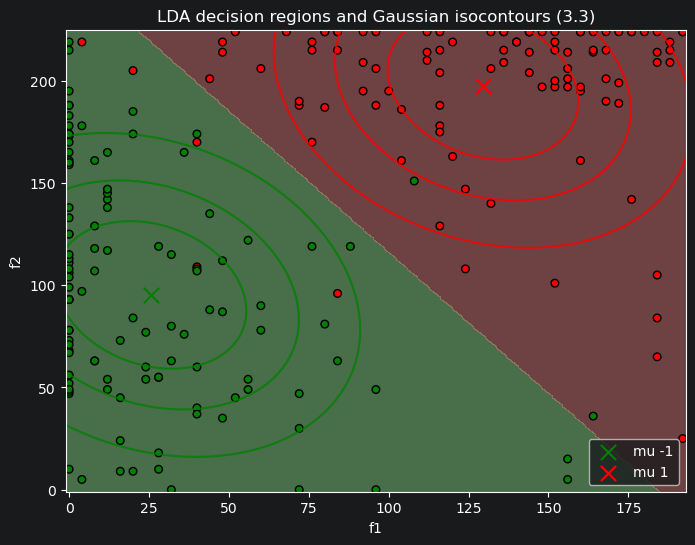

In [63]:
# LDA visualization: decision regions + Gaussian isocontours (Aufgabe 3.3)

# prepare 2D features and labels
train_f2 = features2d(X_train)
Xf2_train = np.array(train_f2).T
Xf2_test = np.array(features2d(X_test)).T
y_train_m = y_train.copy(); y_train_m[y_train_m==3] = -1; y_train_m[y_train_m==9] = 1
y_test_m  = y_test.copy();  y_test_m[y_test_m==3]   = -1; y_test_m[y_test_m==9]   = 1

# fit LDA on the 2D features
mu2, cov2, p2 = fit_lda(Xf2_train, y_train_m)

# grid for plotting decision regions
pad = 1.0
x_min, x_max = Xf2_train[:,0].min() - pad, Xf2_train[:,0].max() + pad
y_min, y_max = Xf2_train[:,1].min() - pad, Xf2_train[:,1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# predict grid labels with our LDA
Z = predict_lda(mu2, cov2, p2, grid).reshape(xx.shape)

# plot decision regions
fig, ax = plt.subplots(figsize=(8,6))
ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["lightgreen", "lightcoral"], alpha=0.4)

# plot training points
colors = ["green" if y == -1 else "red" for y in y_train_m]
ax.scatter(Xf2_train[:,0], Xf2_train[:,1], c=colors, edgecolor='k', s=30)
ax.scatter(mu2[0][0], mu2[0][1], c='green', marker='x', s=120, label='mu -1')
ax.scatter(mu2[1][0], mu2[1][1], c='red',   marker='x', s=120, label='mu 1')

# overlay Gaussian isocontours using the pooled covariance (cov2)
# handle potential singularity
try:
    inv_cov2 = np.linalg.inv(cov2)
    det_cov2 = np.linalg.det(cov2)
except Exception:
    inv_cov2 = np.linalg.pinv(cov2)
    det_cov2 = max(np.linalg.det(cov2), 1e-12)

norm_const = 1.0 / (2 * np.pi * np.sqrt(max(det_cov2, 1e-12)))
for mu_c, col in [(mu2[0], 'green'), (mu2[1], 'red')]:
    diffs = grid - mu_c
    exponents = -0.5 * np.einsum('ij,ij->i', diffs @ inv_cov2, diffs)
    pdf = norm_const * np.exp(exponents)
    pdf2 = pdf.reshape(xx.shape)
    levels = np.linspace(pdf2.min(), pdf2.max(), 5)[1:]
    ax.contour(xx, yy, pdf2, levels=levels, colors=col, alpha=0.8)

ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_title('LDA decision regions and Gaussian isocontours (3.3)')
ax.legend()
plt.show()


<div style="color: green; font-weight: bold">Comment</div>

**Task 3.3 (visualization):** This is a strong visualization of the 2D LDA model: it shows the decision regions, overlays the training data, plots the class means, and adds Gaussian isocontours. The contour overlay is more detailed than the sample solution and is a valid way to represent the Gaussian cluster shapes. The pseudo-inverse fallback is also a reasonable safeguard for nearly singular covariance matrices.


In [64]:
# Aufgabe 3.4: 10-fold CV + sklearn comparison (2D features)
from sklearn.model_selection import KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA

# Prepare 2D data
train_f2 = features2d(X_train)
Xf2_full = np.array(train_f2).T  # Shape (N, 2)
y_full = y_train.copy()
y_full[y_full == 3] = -1
y_full[y_full == 9] = 1

print("=" * 60)
print("Aufgabe 3.4: 10-fold Cross-Validation und sklearn-Vergleich")
print("=" * 60)

# 10-fold CV for our LDA implementation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
our_cv_errors = []
sklearn_cv_errors = []

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(Xf2_full)):
    X_train_fold = Xf2_full[train_idx]
    y_train_fold = y_full[train_idx]
    X_test_fold = Xf2_full[test_idx]
    y_test_fold = y_full[test_idx]
    
    # Our implementation
    mu_fold, cov_fold, p_fold = fit_lda(X_train_fold, y_train_fold)
    preds_our = predict_lda(mu_fold, cov_fold, p_fold, X_test_fold)
    error_our = (preds_our != y_test_fold).mean()
    our_cv_errors.append(error_our)
    
    # sklearn LDA (uses label {-1, 1} natively)
    lda_sklearn = SklearnLDA()
    lda_sklearn.fit(X_train_fold, y_train_fold)
    preds_sklearn = lda_sklearn.predict(X_test_fold)
    error_sklearn = (preds_sklearn != y_test_fold).mean()
    sklearn_cv_errors.append(error_sklearn)
    
    print(f"Fold {fold_idx+1:2d}: Our LDA error={error_our:.4f}, sklearn error={error_sklearn:.4f}")

print("\n" + "=" * 60)
print(f"Our LDA:    Mean CV error = {np.mean(our_cv_errors):.4f} ± {np.std(our_cv_errors):.4f}")
print(f"sklearn LDA: Mean CV error = {np.mean(sklearn_cv_errors):.4f} ± {np.std(sklearn_cv_errors):.4f}")
print("=" * 60)

# Test on full train/test split
mu_full, cov_full, p_full = fit_lda(Xf2_full, y_full)
Xf2_test = np.array(features2d(X_test)).T
y_test_m = y_test.copy()
y_test_m[y_test_m == 3] = -1
y_test_m[y_test_m == 9] = 1

preds_our_full = predict_lda(mu_full, cov_full, p_full, Xf2_full)
preds_our_test = predict_lda(mu_full, cov_full, p_full, Xf2_test)
train_error_our = (preds_our_full != y_full).mean()
test_error_our = (preds_our_test != y_test_m).mean()

lda_sklearn_full = SklearnLDA()
lda_sklearn_full.fit(Xf2_full, y_full)
preds_sklearn_full = lda_sklearn_full.predict(Xf2_full)
preds_sklearn_test = lda_sklearn_full.predict(Xf2_test)
train_error_sklearn = (preds_sklearn_full != y_full).mean()
test_error_sklearn = (preds_sklearn_test != y_test_m).mean()

print("\nTrain/Test Split Results (2D features):")
print(f"Our LDA:     Train error={train_error_our:.4f}, Test error={test_error_our:.4f}")
print(f"sklearn LDA: Train error={train_error_sklearn:.4f}, Test error={test_error_sklearn:.4f}")
print("=" * 60)


Aufgabe 3.4: 10-fold Cross-Validation und sklearn-Vergleich
Fold  1: Our LDA error=0.0455, sklearn error=0.0455
Fold  2: Our LDA error=0.0455, sklearn error=0.0455
Fold  3: Our LDA error=0.0000, sklearn error=0.0000
Fold  4: Our LDA error=0.0455, sklearn error=0.0455
Fold  5: Our LDA error=0.0000, sklearn error=0.0000
Fold  6: Our LDA error=0.0000, sklearn error=0.0000
Fold  7: Our LDA error=0.0455, sklearn error=0.0455
Fold  8: Our LDA error=0.0952, sklearn error=0.0952
Fold  9: Our LDA error=0.0000, sklearn error=0.0000
Fold 10: Our LDA error=0.0476, sklearn error=0.0476

Our LDA:    Mean CV error = 0.0325 ± 0.0301
sklearn LDA: Mean CV error = 0.0325 ± 0.0301

Train/Test Split Results (2D features):
Our LDA:     Train error=0.0323, Test error=0.0274
sklearn LDA: Train error=0.0323, Test error=0.0274


<div style="color: green; font-weight: bold">Comment</div>

**Task 3.4 (quantitative evaluation):** The code correctly implements 10-fold cross-validation and compares the custom LDA implementation with `sklearn`'s `LinearDiscriminantAnalysis`, which is required by the exercise. The comparison is useful because both models are evaluated on the same folds.

The main mismatch is the data used for cross-validation: the exercise asks for cross-validation on all available 3-vs-9 data in the full pixel feature space, while ignoring the earlier train/test split. This code instead cross-validates only on the earlier training split and only on the hand-crafted 2D features. Therefore the result is a valid additional analysis, but it is not directly the requested 3.4 evaluation. To align it with the assignment, the CV should be rerun on the complete filtered 3-vs-9 dataset after removing dead pixels with variance below `0.001`.

# SVM

In [65]:
# Used to be called search_lambda, is a better version of the commented out fit_svm above
def fit_svm(training_features, training_labels):
    # Turn tuple from for_svm_features2d into a matrix
    if type(training_features) == tuple:
        training_features = np.array(training_features).T

    # Test train split
    split = training_features.shape[0] // 5
    validation_features, validation_labels = training_features[:split], training_labels[:split]
    training_features, training_labels   = training_features[split:], training_labels[split:]


    n = training_features.shape[0]
    beta0 = np.random.normal(size=(training_features.shape[1])) # Random initial guess
    lambs = np.logspace(-4, 2, num=7) # 7 different lambdas on a log scale

    # Need to store best iteration for training
    best_lambda = 1
    best_beta = None
    best_b = None
    best_loss = 100000

    # Losses and error will be stored to graph later
    b_losses = []
    b_errors = []

    # Iterate through each lambda picked earlier
    for lamb in lambs:
        # Reset stored losses and errors so they are per lambda (we store the best one at the end)
        t_loss = []
        t_error = []

        # Reset fresh per new lambda value
        loss_old = 100000
        count = 0
        beta = beta0.copy()
        b = 0
        tau = 1

        # Gradient descent with 10,000 iterations
        for x in range(10000):
            mask = (1 - training_labels * (training_features @ beta + b)) > 0                                           # Mask for misclassifications
            grad_beta = beta + lamb/n * (-training_labels[mask, np.newaxis] * training_features[mask]).sum(axis=0)
            beta = beta - tau * grad_beta
            grad_b = lamb/n * (-training_labels[mask]).sum()
            b = b - tau * grad_b

            loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
            t_loss.append(loss) # For visualizing the training loss later

            iteration_error = calculate_errors(predict_svm(training_features, beta, b), training_labels)[5]
            t_error.append(iteration_error) # Need to visualize the training error

            # Check for Training Error Stagnation and reduce learning rate to keep optimizing
            if loss >= loss_old and count >= 10:
               count = 0
               tau /= 10
            elif loss >= loss_old and count < 10:
               count += 1
            else:
               loss_old = loss

        # Measure train loss, validation loss, validation accuracy, validation error, and best loss for each lambda iteration
        valid_loss = 1/2 * beta @ beta.T + 1/n * (np.maximum(0, 1 - validation_labels * (validation_features @ beta + b))).sum()
        predicted_labels = predict_svm(validation_features, beta, b)
        errors = calculate_errors(predicted_labels, validation_labels)

        # Print metrics calculated above
        print(f"lambda: {lamb}, training loss: {loss:.4f}, validation loss: {valid_loss:.4f}, valid acc: {errors[5]:.4f}, valid error: {errors[6]:.4f}, best loss:{best_loss:.4f}")

        # Check if current iteration is the best one yet
        if valid_loss < best_loss:
            # Save errors for graphing later
            b_losses = t_loss
            b_errors = t_error

            # Update best found so far
            best_loss = valid_loss
            best_lambda = lamb.copy()
            best_beta = beta.copy()
            best_b = b.copy()

    return best_lambda, best_beta, best_b, b_losses, b_errors

def predict_svm(test_features, beta, b):
    # Turn tuple from for_svm_features2d into a matrix
    if type(test_features) == tuple:
        test_features = np.array(test_features).T

    # SVM decision rule
    predicted_labels = test_features @ beta + b

    # Convert to class label
    predicted_labels[predicted_labels > 0] = 1
    predicted_labels[predicted_labels < 0] = -1
    
    return predicted_labels

# np.random.seed(6707)

best_lambda = fit_svm(X_train, y_train)
print("Best Lambda found: ", best_lambda[0])

lambda: 0.0001, training loss: 0.0001, validation loss: 0.2455, valid acc: 0.5349, valid error: 0.4651, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2313, valid acc: 0.5349, valid error: 0.4651, best loss:0.2455
lambda: 0.01, training loss: 0.0055, validation loss: 0.0814, valid acc: 0.0000, valid error: 1.0000, best loss:0.2313
lambda: 0.1, training loss: 0.0695, validation loss: 0.0725, valid acc: 0.0233, valid error: 0.9767, best loss:0.0814
lambda: 1.0, training loss: 3.4790, validation loss: 3.2093, valid acc: 0.0233, valid error: 0.9767, best loss:0.0725
lambda: 10.0, training loss: 354.1903, validation loss: 323.9679, valid acc: 0.0233, valid error: 0.9767, best loss:0.0725
lambda: 100.0, training loss: 9200.7374, validation loss: 8446.6754, valid acc: 0.0233, valid error: 0.9767, best loss:0.0725
Best Lambda found:  0.1


<div style="color: green; font-weight:bold">Comment</div>
Our solution for predict_svm is essentially equal to the sample solution but done without the np.sign function, our solution has the addition of a tuple check. The sample solution breaks up the SVM into fit_svm and cross_validation_SVM in order to find optimal lambdas but in our function we do all the work in the fit_svm function. The code is essentially equal in that we both do gradiant descent and find the best lambda. Our function runs uses more iterations at 10,000 compared to the sample solution's 1,000. This may be redundant as the problem set is simple and the optimal solution converges before even reaching 1000 as seen in the graphs below so we have redundant steps. The extra iterations should be cut down to make the code more performant. Our solution does include changing the tau to prevent training error stagnation, this is an improvement over the sample solution. Our errors do end up being worse than the sample solution and it is most likely because our lambda search did not look high enough, as the sample finds 100 or 1000 get the best results (for reduced pixel vector) while our search only goes between 0.0001 and 100. The other potential error is we did not use a k-fold split but a simple 20% validation split. The overall general logic of the SVM is all contained within our functions though.

In [66]:
# 2D version of the feature space made with hand-crafted classifier
def for_svm_features2d(x: np.array):
    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2
    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

    return f_1, f_2

In [67]:
# Used to be function calls for search_lambda, now swapped with fit_svm
_, beta, b, t_loss_full, t_error_full = fit_svm(X_train, y_train) # Full features
_, beta_2, b_2, t_loss_reduced, t_error_reduced = fit_svm(for_svm_features2d(X_train), y_train) # Reduced features

# Show fit_svm
beta, b, beta_2, b_2

lambda: 0.0001, training loss: 0.0001, validation loss: 0.2455, valid acc: 0.5349, valid error: 0.4651, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2241, valid acc: 0.5116, valid error: 0.4884, best loss:0.2455
lambda: 0.01, training loss: 0.0056, validation loss: 0.0985, valid acc: 0.0233, valid error: 0.9767, best loss:0.2241
lambda: 0.1, training loss: 0.0653, validation loss: 0.0712, valid acc: 0.0233, valid error: 0.9767, best loss:0.0985
lambda: 1.0, training loss: 5.3721, validation loss: 4.9353, valid acc: 0.0465, valid error: 0.9535, best loss:0.0712
lambda: 10.0, training loss: 488.2613, validation loss: 453.5451, valid acc: 0.0465, valid error: 0.9535, best loss:0.0712
lambda: 100.0, training loss: 8084.3524, validation loss: 7287.2779, valid acc: 0.0000, valid error: 1.0000, best loss:0.0712
lambda: 0.0001, training loss: 0.0001, validation loss: 0.1934, valid acc: 0.4419, valid error: 0.5581, best loss:100000.0000
lambda: 0.001, training 

(array([ 0.        , -0.00695347, -0.03314658, -0.02907627, -0.03667642,
        -0.02993545,  0.00595743,  0.00042087,  0.        , -0.01245744,
         0.00832369,  0.00203529, -0.01575704,  0.00133412, -0.0003601 ,
         0.001433  ,  0.        ,  0.03560043,  0.13818206,  0.04669853,
        -0.04891816,  0.0900907 ,  0.03518263,  0.00121455,  0.        ,
         0.03371664,  0.1477933 ,  0.06232206, -0.0109769 ,  0.13292121,
         0.0690441 ,  0.        ,  0.        ,  0.00206877,  0.02612795,
        -0.00647023, -0.11307081,  0.00399754,  0.04947283,  0.        ,
         0.        , -0.00669008, -0.02124573, -0.01143615, -0.03937902,
        -0.03617366, -0.00167153,  0.        ,  0.        , -0.00693781,
        -0.02351388, -0.02571067, -0.05064058, -0.04710632,  0.00120159,
         0.00170511,  0.        , -0.00557851, -0.04383124, -0.03461546,
        -0.00365981,  0.01131286,  0.02228308,  0.0011178 ]),
 np.float64(-0.045971966794380544),
 array([0.04038555, 0.0459

<div style="color: green; font-weight:bold">Comment</div>
Cross validation of reduced and full pixel vector is effectively the same as the sample solution.

In [68]:
# Test predictions on the SVM
predicted_labels_svm = predict_svm(X_test, beta, b)
predicted_labels_svm2 = predict_svm(for_svm_features2d(X_test), beta_2, b_2)

# Show predictions
predicted_labels_svm, predicted_labels_svm2

(array([ 1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1.,
        -1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1., -1., -1., -1., -1.,
        -1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,
        -1., -1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.,
         1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,  1.,
         1., -1.,  1., -1.,  1., -1., -1., -1., -1.,  1., -1., -1., -1.,
         1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1.,  1.,
        -1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1., -1., -1.,
         1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1., -1.,
         1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1., -1.,
        -1.,  1.,  1.]),
 array([ 1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1., -1., -1.,  1.,
        -1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1., -1., -1., -1., -1.,
        -1.,  1.,  1., -1.

In [69]:
# Compare errors from the full features and 2d features
errors_svm_1 = calculate_errors(predicted_labels_svm, true_labels)
errors_svm_2 = calculate_errors(predicted_labels_svm2, true_labels)

# Show errors
errors_svm_1, errors_svm_2

((np.int64(74),
  np.int64(68),
  np.int64(4),
  np.int64(0),
  146,
  np.float64(0.0273972602739726),
  np.float64(0.9726027397260274)),
 (np.int64(70),
  np.int64(68),
  np.int64(4),
  np.int64(4),
  146,
  np.float64(0.0547945205479452),
  np.float64(0.9452054794520548)))

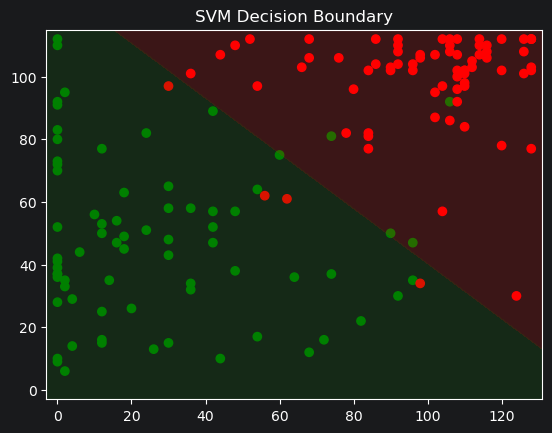

In [70]:
# SVM visualization: decision boundaries

# prepare 2D features and labels (fit SVM on the 2D features)
training_features_svm = for_svm_features2d(X_train)
test_features_svm = for_svm_features2d(X_test)

# utilize same colors from 2
color_dict = {-1: "green", 1: "red"}
colors = [color_dict[y] for y in true_labels]

# grid for plotting decision regions
pad = 3.0
x_min, x_max = training_features_svm[0].min() - pad, training_features_svm[0].max() + pad
y_min, y_max = training_features_svm[1].min() - pad, training_features_svm[1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = (xx.ravel(), yy.ravel())

# plot training points
fig, ax = plt.subplots()
ax.scatter(test_features_svm[0], test_features_svm[1], c=colors)

# predict grid labels with our SVM
Z = predict_svm(grid, beta_2, b_2).reshape(xx.shape)

# plot decision regions
ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["green", "red"], alpha=0.15)
ax.set_title("SVM Decision Boundary")
plt.show()

<div style="color: green; font-weight:bold">Comment</div>
This graph is in line with the sample solution and is a good representation of the decision boundary of the SVM. The graph could be more clear that the green points are 3s and the red points are 9s. The axis could also be labelled as 'feature 1' and 'feature 2' similar to the sample solution for more readability.

In [71]:
# Compare against sklearn's Official Linear Support Vector Classification
from sklearn.svm import LinearSVC

# Prepare 2D features and labels
Xf2_train_svm = np.array(for_svm_features2d(X_train)).T
Xf2_test_svm = np.array(for_svm_features2d(X_test)).T
y_train_svm = y_train.copy(); y_train_svm[y_train_svm==3] = -1; y_train_svm[y_train_svm==9] = 1
y_test_svm  = y_test.copy();  y_test_svm[y_test_svm==3]   = -1; y_test_svm[y_test_svm==9]   = 1

# Our implementation (fit called earlier and populated variables beta_2, b_2)
train_error_our_svm = calculate_errors(predict_svm(Xf2_train_svm, beta_2, b_2), y_train_svm)[5]
test_error_our_svm = calculate_errors(predict_svm(Xf2_test_svm, beta_2, b_2), y_test_svm)[5]

# Utilize SVM LinearSVC from sklearn
svm_sklearn = LinearSVC()
svm_sklearn.fit(Xf2_train_svm, y_train_svm)

preds_sklearn_train_svm = svm_sklearn.predict(Xf2_train_svm)
preds_sklearn_test_svm = svm_sklearn.predict(Xf2_test_svm)

train_error_sklearn_svm = (preds_sklearn_train_svm != y_train_svm).mean()
test_error_sklearn_svm = (preds_sklearn_test_svm != y_test_svm).mean()

print("\nTrain/Test Split Results (2D Features): ")
print(f"Our SVM:       Train Error = {train_error_our_svm:.4f}, Test Error = {test_error_our_svm:.4f}")
print(f"Sklearn SVM:   Train Error = {train_error_sklearn_svm:.4f}, Test Error = {test_error_sklearn_svm:.4f}")


Train/Test Split Results (2D Features): 
Our SVM:       Train Error = 0.0599, Test Error = 0.0548
Sklearn SVM:   Train Error = 0.0645, Test Error = 0.0685


####  In addition, compare your results with the results from the official linear support vector classification in the sklearn package. How does the prediction quality change relative to LDA and the nearest mean classifier?
We can see that the official linear support vector classifier in the sklearn package far outperforms our SVM. This is because we use a hand-crafted feature as well as a simple learning rate schedule optimization compared to more complicated techniques utilized by the sklearn package. In comparison to our LDA, our SVM performs worse, though the sklearn LDA performs has a lower error (2.74%) than the sklearn SVM error (6.85%) as well, implying that the SVM is not good for this particular problem set. The nearest mean performs the best out of all of them with the best error (2.05%). (SVM error can change because of the random beta0 initialization, so this is taken from one run)

<div style="color: green; font-weight:bold">Comment</div>
This code correctly compares the training and test error of our SVM to sklearn's provided SVM function.

# Plotting
#### Visualize in a diagram how the Loss and the training error change in the course of iteration.

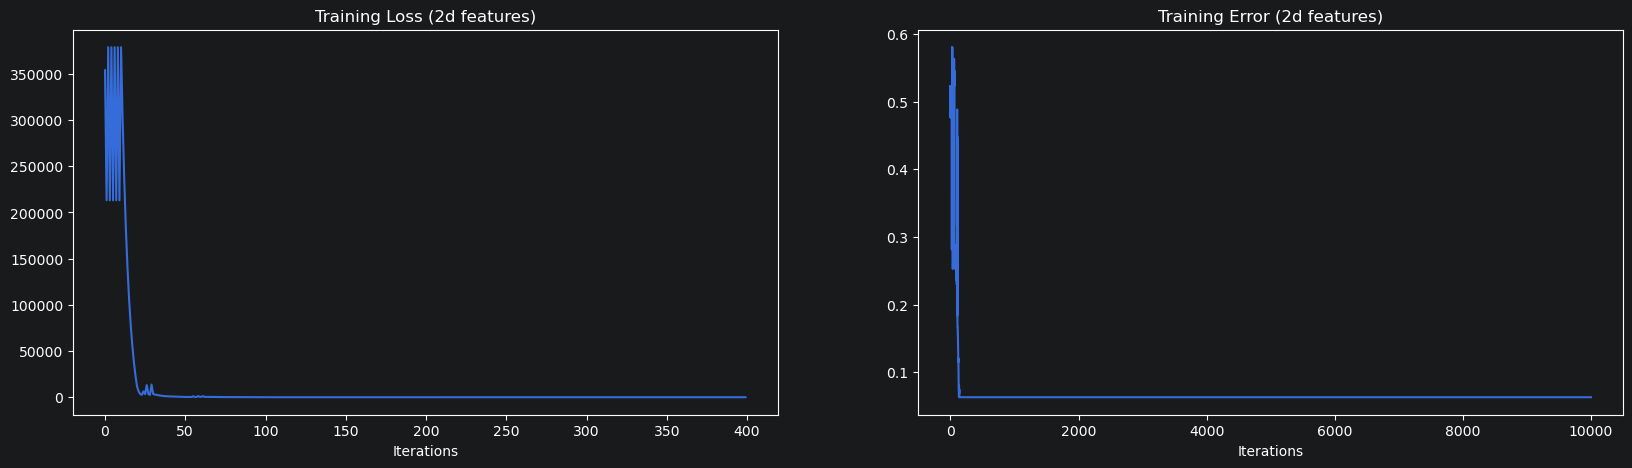

In [72]:
# Best Lambda for 2D Features: Visualize in a diagram how the Loss and the training error change in the course of iteration.
iterations = range(len(t_loss_reduced))

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].set_xlabel("Iterations")
axes[0].set_title("Training Loss (2d features)")
axes[0].plot(range(400), t_loss_reduced[:400])

axes[1].set_xlabel("Iterations")
axes[1].set_title("Training Error (2d features)")
axes[1].plot(iterations, t_error_reduced)
plt.show()

<div style="color: green; font-weight:bold">Comment</div>
The general graphs display the correct results for a decreasing slope of trianing loss and a more messy up and down training error decrease as iterations go on. The graphs displayed have to large of an x axis which makes this hard to see compared to the solution answer. This can be fixed by adjusting the axis similar to axes[0].plot(range(400), t_loss_reduced[:400]), which makes the decrease more readable. Same principles apply to the graphs below.

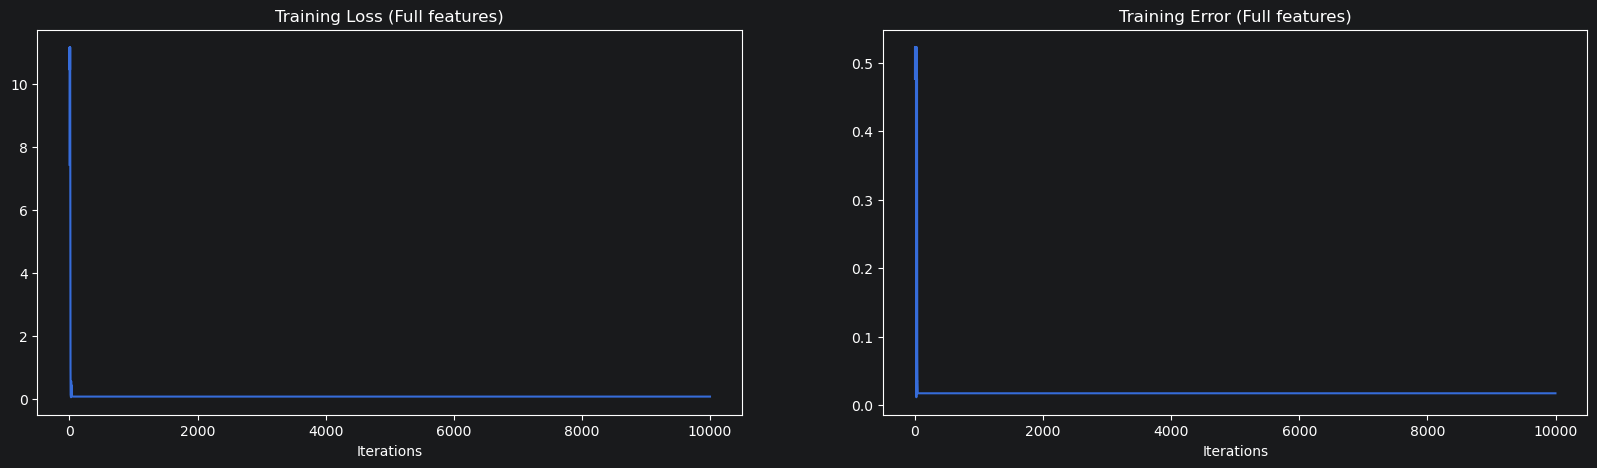

In [73]:
# Best lambda for full features visualization
iterations = range(len(t_loss_full))

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].set_xlabel("Iterations")
axes[0].set_title("Training Loss (Full features)")
axes[0].plot(iterations, t_loss_full)

axes[1].set_xlabel("Iterations")
axes[1].set_title("Training Error (Full features)")
axes[1].plot(iterations, t_error_full)
plt.show()